# Droplet / Single-Photon Clustering

Pixel detectors (CCDs, sCMOS, hybrid photon-counting chips, ...) rarely
deposit a single photon's energy into exactly one pixel. The charge cloud a
photon creates usually straddles two or more neighbouring pixels, splitting
its energy between them depending on exactly where it landed relative to the
pixel grid. Read the *single* brightest pixel and you get a biased, smeared
estimate of the photon's true energy. Sum the whole connected cluster of
above-threshold pixels ("droplet") instead, and you recover the true energy
-- this is the classic **droplet algorithm** / single-photon-counting
technique used at synchrotron and FEL beamlines (RIXS, soft X-ray CCDs,
serial crystallography hit-finding, ...).

This notebook demonstrates `escape.utilities_detectors.find_droplets`,
applied to a synthetic detector stack wrapped in an `escape.Array`. It
covers:

1. Generating a synthetic charge-sharing photon-counting dataset
2. Why naive per-pixel readout gives smeared histograms
3. `find_droplets(..., mode="image")` -- collapse each droplet onto its
   centroid pixel for a clean, drop-in replacement of the raw frames
4. `find_droplets(..., mode="sparse")` -- emit a compact per-frame event
   list instead, for large data reduction at low occupancy
5. How this scales to large stacks / a SLURM-backed dask cluster without
   ever materializing the full stack in memory


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

import escape
from escape.storage.example_data import make_detector_photon_stack
from escape.utilities_detectors import find_droplets

print(f"escape version: {escape.__version__}")

escape version: 0.1.3.dev0+gd06cbf433.d20260709


## Synthetic Dataset

`make_detector_photon_stack` builds a stack of 2-D detector frames: each
frame gets a Poisson-distributed number of photon hits at random sub-pixel
positions, each depositing a fixed-ish energy (`photon_energy`, with a small
`energy_jitter`) as a 2-D Gaussian charge cloud of width `droplet_sigma`
pixels, correctly integrated over each pixel's area (via `erf`) so the
split between neighbours really does depend on the hit's position relative
to the pixel grid -- plus Gaussian read noise on every pixel.

The result is returned as a dask-backed `escape.Array`, shape
`(n_events, n_rows, n_cols)`, chunked along the event axis -- the same
representation a real detector stack loaded from disk would have.

In [2]:
frames = make_detector_photon_stack(
    n_events=300,
    frame_shape=(128, 128),
    mean_photons=6.0,      # average hits per frame
    photon_energy=100.0,   # true (quasi-monochromatic) photon energy, ADU
    energy_jitter=3.0,     # small intrinsic energy spread
    droplet_sigma=0.25,    # charge-cloud width, in pixels
    read_noise=1.5,        # detector read noise, ADU
    seed=0,
)
frames

In [3]:
print("shape:", frames.shape)
print("dask chunks along the event axis:", frames.data.chunks[0])

shape: (300, 128, 128)
dask chunks along the event axis: (50, 50, 50, 50, 50, 50)


## A Raw Frame

Zooming into a couple of hits shows the charge already spreading across
more than one pixel -- some hits land close to a pixel centre (most energy
in one pixel), others straddle a boundary (energy split between two or more
pixels).

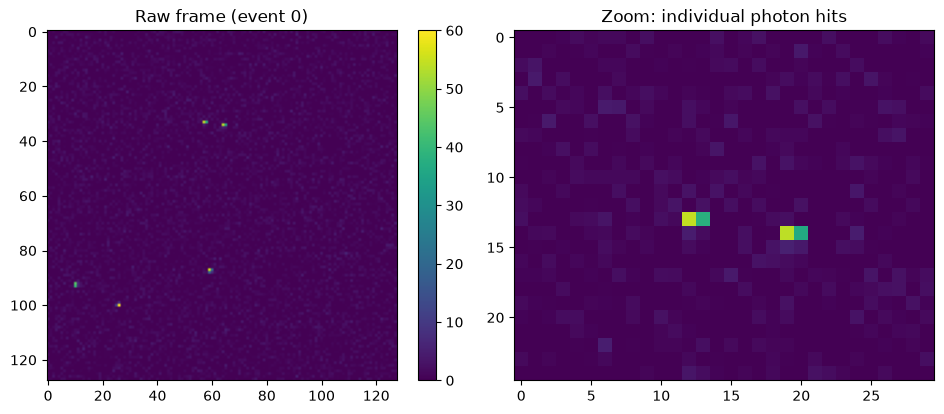

In [4]:
raw_preview = frames.data[:1].compute()[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im = axes[0].imshow(raw_preview, vmin=0, vmax=60, cmap="viridis")
axes[0].set_title("Raw frame (event 0)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(raw_preview[20:45, 45:75], vmin=0, vmax=60, cmap="viridis")
axes[1].set_title("Zoom: individual photon hits")
fig.tight_layout()

## The Problem: Naive Single-Pixel Readout

A threshold a few $\sigma$ above the read-noise floor cleanly separates
signal from noise -- but if you then just read out the *brightest pixel* of
each connected cluster as "the" photon energy, the result depends heavily
on where the photon happened to land relative to the pixel grid. Summing
the whole connected cluster instead recovers the true energy.

The cell below computes both quantities directly with `scipy.ndimage`, one
frame at a time, purely to illustrate what `find_droplets` automates.

In [5]:
read_noise = 1.5
threshold = 5 * read_noise  # ~5 sigma above the noise floor

raw = frames.data.compute()  # small synthetic stack -- fine to pull into memory here

max_per_droplet, sum_per_droplet = [], []
for frame in raw:
    labeled, n = ndi.label(frame > threshold)
    if n == 0:
        continue
    idx = np.arange(1, n + 1)
    max_per_droplet.append(ndi.maximum(frame, labeled, idx))
    sum_per_droplet.append(ndi.sum(frame, labeled, idx))
max_per_droplet = np.concatenate(max_per_droplet)
sum_per_droplet = np.concatenate(sum_per_droplet)

print(f"{len(sum_per_droplet)} photon hits found (expected ~{6.0 * 300:.0f})")
print(f"naive single-pixel : mean={max_per_droplet.mean():5.1f}  std={max_per_droplet.std():4.1f}  "
      f"(CV {max_per_droplet.std() / max_per_droplet.mean() * 100:.0f}%)")
print(f"droplet-summed     : mean={sum_per_droplet.mean():5.1f}  std={sum_per_droplet.std():4.1f}  "
      f"(CV {sum_per_droplet.std() / sum_per_droplet.mean() * 100:.0f}%)")

1783 photon hits found (expected ~1800)
naive single-pixel : mean= 63.9  std=15.7  (CV 25%)
droplet-summed     : mean= 94.9  std= 7.5  (CV 8%)


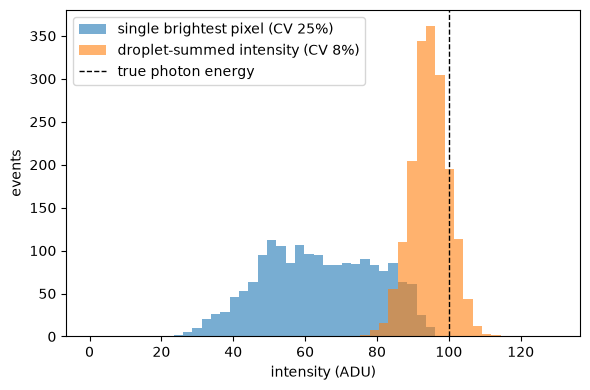

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(max_per_droplet, bins=50, range=(0, 130), alpha=0.6,
        label=f"single brightest pixel (CV {max_per_droplet.std() / max_per_droplet.mean() * 100:.0f}%)")
ax.hist(sum_per_droplet, bins=50, range=(0, 130), alpha=0.6,
        label=f"droplet-summed intensity (CV {sum_per_droplet.std() / sum_per_droplet.mean() * 100:.0f}%)")
ax.axvline(100, color="k", ls="--", lw=1, label="true photon energy")
ax.set_xlabel("intensity (ADU)")
ax.set_ylabel("events")
ax.legend()
fig.tight_layout()

Summing the connected cluster nearly triples the energy resolution (much
smaller coefficient of variation) *and* removes the systematic
under-estimate from splitting -- exactly the "much better histograms"
motivation for droplet finding.

## `find_droplets`, `mode="image"`

`escape.utilities_detectors.find_droplets` automates the clustering above
-- vectorized with `scipy.ndimage` across a whole dask chunk at once (not a
Python loop per frame like above), and run lazily via
`Array.map_index_blocks` so only one chunk of frames is ever materialized
per task. `mode="image"` collapses each droplet onto its centroid pixel,
giving a same-shape drop-in replacement for the raw frames.

In [7]:
clustered = find_droplets(frames, threshold=threshold, mode="image")
print("lazy dask-backed result:", clustered.is_dask_array())
clustered = clustered.compute()

lazy dask-backed result: True
[                                        ] | 0% Completed | 374.28 us

[########################################] | 100% Completed | 101.65 ms

1783 droplets, mean=94.9, std=7.5 -- matches the by-hand calculation above.


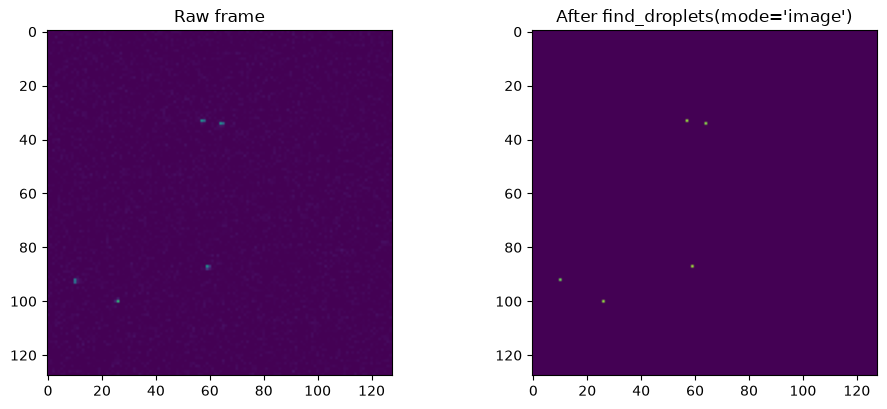

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].imshow(raw[0], vmin=0, vmax=110, cmap="viridis")
axes[0].set_title("Raw frame")
axes[1].imshow(clustered.data[0], vmin=0, vmax=110, cmap="viridis")
axes[1].set_title("After find_droplets(mode='image')")
fig.tight_layout()

clustered_hits = clustered.data[clustered.data > 0]
print(f"{clustered_hits.size} droplets, mean={clustered_hits.mean():.1f}, "
      f"std={clustered_hits.std():.1f} -- matches the by-hand calculation above.")

## `find_droplets`, `mode="sparse"` — Data Reduction

At low occupancy, most of a dense frame is empty. `mode="sparse"` returns a
fixed-capacity `(max_droplets, 3)` array of `(row, col, intensity)` per
event (NaN-padded) instead of a full image -- here that's already a ~55x
size reduction even with generous, mostly-unused padding; unpacking the
real (non-NaN) events into a plain table shows the *actual* information
content is far smaller still.

In [9]:
events = find_droplets(
    frames, threshold=threshold, mode="sparse", max_droplets=50, chunk_size=50,
)
events = events.compute()
sd = events.data
print("sparse array shape:", sd.shape)

frame_i, slot_i = np.where(~np.isnan(sd[..., 2]))
events_df = pd.DataFrame({
    "frame": frame_i,
    "row": sd[frame_i, slot_i, 0],
    "col": sd[frame_i, slot_i, 1],
    "intensity": sd[frame_i, slot_i, 2],
})
events_df.head()

[                                        ] | 0% Completed | 304.31 us

[########################################] | 100% Completed | 102.01 ms

sparse array shape: (300, 50, 3)


,frame,row,col,intensity
0,0,87.202249,59.205210,93.941267
1,0,33.000000,57.411179,92.465004
2,0,99.908622,25.876048,91.695836
3,0,34.000000,64.402294,90.420811
4,0,92.478034,10.000000,85.124096


In [10]:
dense_MB = raw.nbytes / 1e6
sparse_padded_MB = sd.nbytes / 1e6
events_MB = events_df.memory_usage(deep=True).sum() / 1e6

print(f"dense stack:            {dense_MB:6.2f} MB")
print(f"sparse (padded) result: {sparse_padded_MB:6.2f} MB  ({dense_MB / sparse_padded_MB:.0f}x smaller)")
print(f"unpadded event table:   {events_MB:6.3f} MB  ({dense_MB / events_MB:.0f}x smaller)")

dense stack:             19.66 MB
sparse (padded) result:   0.36 MB  (55x smaller)
unpadded event table:    0.057 MB  (344x smaller)


## Scaling to Large, Out-of-Core Stacks

Everything above ran lazily, one dask chunk at a time -- `find_droplets`
never materializes more than a single chunk of frames per task. That means
it's memory-safe for detector stacks far larger than a single machine's
RAM, and it scales unchanged onto a SLURM-backed dask cluster via
`dask_jobqueue`: each task still only ever touches its own chunk, so a
1000x1000-pixel stack with 10^5+ frames never needs to fit on one node.

```python
from escape.swissfel.cluster import SwissFelCluster

cluster = SwissFelCluster(
    local=False, cores=4, memory="8 GB", workers=20, processes=1,
)

events = find_droplets(
    detector_stack, threshold=15.0, mode="sparse",
    max_droplets=200, chunk_size=50,
)
events = events.persist()   # scatters computation over the SLURM workers
events.compute()            # gather only the (small) sparse result
```

See `escape.utilities_detectors.find_droplets` for the full docstring and
`escape.swissfel.cluster.SwissFelCluster` for cluster options.